In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

# Librerías de Modelado y Preprocesamiento
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder

# Librerías SDV (Sintetización de datos)
from sdv.metadata import SingleTableMetadata
from sdv.single_table import CTGANSynthesizer
from sdv.evaluation.single_table import run_diagnostic, evaluate_quality

# Configuración de estilo y warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# 1. Configuración de Rutas (Relativas al notebook)
DATA_PATH = Path("../data/processed/brfss_2023_cleaned.csv")
FIGURES_DIR= Path("../reports/figures") 
# 2. Constantes del Modelo
RANDOM_SEED = 42
TEST_SIZE = 0.2
N_FOLDS = 5
TARGET_COL = "categoria_imc"

# 3. Definición del orden lógico del Target
ORDEN_IMC = ["bajo_peso", "normal", "sobrepeso", "obesidad"]
COLS_CONTINUAS = ["edad", "salud_fisica_mala", "salud_mental_mala"]

# verificación
print("clases y sus códigos:")
for clase, codigo in MAPEO_TARGET.items():
    print(f"  {codigo} → {clase}")
ORDENES = {
    "nivel_educativo":  ["sin_estudios", "basica", "secundaria", "universitaria"],
    "nivel_ingresos":   ["menos_15k", "15k_25k", "25k_35k", "35k_50k", "50k_100k", "100k_200k", "mas_200k"],
    "categoria_imc":    ["bajo_peso", "normal", "sobrepeso", "obesidad"],
}

# 4. Carga de datos
try:
    df = pd.read_csv(DATA_PATH)
    
    # Aplicar orden categórico
    df[TARGET_COL] = pd.Categorical(
        df[TARGET_COL], 
        categories=ORDEN_IMC, 
        ordered=True
    )
    
    print(f" Dataset cargado exitosamente: {df.shape}")
    print(f" Orden del target: {df[TARGET_COL].cat.categories.tolist()}")
except FileNotFoundError:
    print(f" Error: No se encontró el archivo en {DATA_PATH.absolute()}")



# 5. Inicialización de LabelEncoder para modelos que lo requieran
le = LabelEncoder()


clases y sus códigos:
  0 → bajo_peso
  1 → normal
  2 → sobrepeso
  3 → obesidad
 Dataset cargado exitosamente: (289693, 12)
 Orden del target: ['bajo_peso', 'normal', 'sobrepeso', 'obesidad']


## Estrategia de partición de datos y validación

El análisis exploratorio reveló un desbalance marcado en `categoria_imc`
— la clase `bajo_peso` representa apenas el 1.68% del total. Una
partición aleatoria simple no es viable aquí: con tan pocos registros
en esa clase, un split aleatorio podría dejarla casi ausente en train
o en test, impidiendo que el modelo aprenda a identificarla o que
podamos evaluarla correctamente.

**División estratificada (80/20):** la estratificación garantiza que
ambos conjuntos preserven la proporción original de cada clase. Es el
paso más crítico del pipeline dado el desbalance documentado.

**Validación cruzada estratificada (k=5):** en lugar de depender de
una sola partición, rotamos los datos de entrenamiento y validación
cinco veces. La métrica final es el promedio de los 5 folds — más
estable y menos dependiente del azar que una evaluación única.

**Reproducibilidad:** `RANDOM_SEED = 42` fija todas las operaciones
aleatorias del pipeline para garantizar resultados consistentes entre
ejecuciones.

In [20]:
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# 2. Creación de los conjuntos de entrenamiento y prueba
# Usamos stratify=y para mantener la proporción de las clases de IMC
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=TEST_SIZE, 
    random_state=RANDOM_SEED, 
    stratify=y
)
print(f"train: {X_train.shape} | test: {X_test.shape}")
print("\nproporción de clases en train:")
print(y_train.value_counts(normalize=True).round(4))
print("\nproporción de clases en test:")
print(y_test.value_counts(normalize=True).round(4))

train: (231754, 11) | test: (57939, 11)

proporción de clases en train:
categoria_imc
sobrepeso    0.3591
obesidad     0.3403
normal       0.2854
bajo_peso    0.0152
Name: proportion, dtype: float64

proporción de clases en test:
categoria_imc
sobrepeso    0.3591
obesidad     0.3403
normal       0.2854
bajo_peso    0.0152
Name: proportion, dtype: float64


## Estrategia de codificación de variables categóricas

La elección del encoder impacta directamente en la capacidad predictiva
de los modelos. Según benchmarks recientes (NeurIPS 2023, arXiv 2024),
no existe un ganador universal — las mejores prácticas dependen de la
arquitectura del modelo.

**Modelos lineales (Logistic Regression) → One-Hot Encoding:**
la literatura confirma que es la opción óptima para modelos que realizan
transformaciones afines. Evita que el modelo asuma una jerarquía
inexistente entre categorías nominales.

**Modelos basados en árboles (Random Forest, XGBoost) → Ordinal Encoding:**
aunque estudios recientes sugieren que target encoding puede ser superior
para árboles, introduce riesgo elevado de data leakage si no se implementa
dentro de una validación cruzada anidada. Data leakage ocurre cuando
información del conjunto de prueba se filtra al entrenamiento — el modelo
aprende indirectamente los valores del test set y sus métricas quedan
artificialmente infladas.

**Decisión pragmática:** para mantener la integridad metodológica,
usamos ordinal encoding para los árboles preservando el orden lógico
de las categorías ordinales (`nivel_educativo`, `nivel_ingresos`,
`categoria_imc`) sin contaminar los predictores con información del
target.

In [23]:
# identificar columnas por tipo
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()

# orden lógico para variables ordinales
# para nominales sin orden definido, usar categorías únicas del train
categorias_ordenadas = []
for col in cat_cols:
    if col in ORDENES:
        categorias_ordenadas.append(ORDENES[col])
    else:
        categorias_ordenadas.append(sorted(X_train[col].dropna().unique().tolist()))

# --- versión 1: one-hot encoding (logistic regression) ---
ohe = OneHotEncoder(sparse_output=False, drop="first", handle_unknown="ignore")

X_train_ohe = pd.concat([
    pd.DataFrame(
        ohe.fit_transform(X_train[cat_cols]),
        columns=ohe.get_feature_names_out(cat_cols),
        index=X_train.index
    ),
    X_train[num_cols]
], axis=1)

X_test_ohe = pd.concat([
    pd.DataFrame(
        ohe.transform(X_test[cat_cols]),
        columns=ohe.get_feature_names_out(cat_cols),
        index=X_test.index
    ),
    X_test[num_cols]
], axis=1)

# --- versión 2: ordinal encoding (random forest y xgboost) ---
ord_enc = OrdinalEncoder(
    categories=categorias_ordenadas,
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

X_train_ord = X_train.copy()
X_test_ord = X_test.copy()

X_train_ord[cat_cols] = ord_enc.fit_transform(X_train[cat_cols])
X_test_ord[cat_cols] = ord_enc.transform(X_test[cat_cols])

# --- target: mapeo manual con orden clínico lógico ---
MAPEO_TARGET = {
    "bajo_peso": 0,
    "normal":    1,
    "sobrepeso": 2,
    "obesidad":  3
}

y_train_enc = y_train.map(MAPEO_TARGET)
y_test_enc  = y_test.map(MAPEO_TARGET)

# verificación final
print(f"features one-hot : {X_train_ohe.shape[1]}")
print(f"features ordinal : {X_train_ord.shape[1]}")
print("\nclases y sus códigos:")
for clase, codigo in MAPEO_TARGET.items():
    print(f"  {codigo} -> {clase}")

features one-hot : 26
features ordinal : 11

clases y sus códigos:
  0 -> bajo_peso
  1 -> normal
  2 -> sobrepeso
  3 -> obesidad


## Modelo baseline

Antes de entrenar cualquier modelo, establecemos un baseline — una
estrategia naive que sirve como piso mínimo de referencia. Sin él,
no podemos saber si un modelo complejo está aprendiendo patrones
reales o simplemente reflejando la distribución del target.

En clasificación multiclase con desbalance, el baseline más simple
es predecir siempre la clase más frecuente. Esta estrategia ignora
completamente los predictores y se basa únicamente en las proporciones
del target.

Con `sobrepeso` representando el 35.6% del dataset, el baseline
alcanzará exactamente ese accuracy — 35.6% — sin aprender nada.
Cualquier modelo que no supere ese umbral no justifica su complejidad.

In [28]:
from sklearn.dummy import DummyClassifier

# baseline: predice siempre la clase más frecuente
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_SEED)
dummy.fit(X_train_ohe, y_train_enc)

y_pred_baseline = dummy.predict(X_test_ohe)

print("resultados del baseline (clase más frecuente):")
print(f"accuracy: {accuracy_score(y_test_enc, y_pred_baseline):.4f}")
print()
print(classification_report(
    y_test_enc,
    y_pred_baseline,
    target_names=["bajo_peso", "normal", "sobrepeso", "obesidad"]
))

resultados del baseline (clase más frecuente):
accuracy: 0.3591

              precision    recall  f1-score   support

   bajo_peso       0.00      0.00      0.00       879
      normal       0.00      0.00      0.00     16537
   sobrepeso       0.36      1.00      0.53     20808
    obesidad       0.00      0.00      0.00     19715

    accuracy                           0.36     57939
   macro avg       0.09      0.25      0.13     57939
weighted avg       0.13      0.36      0.19     57939



## Evaluación del baseline

El baseline alcanza una accuracy de **35.9%**, confirmando que es un
punto de referencia débil — no utiliza ningún predictor, solo la
distribución del target. Cualquier modelo que capture patrones reales
debería superarlo sin dificultad.

Sin embargo, la observación más importante es el **F1-macro de 0.13**.
A diferencia del accuracy, el F1-macro evalúa el desempeño de forma
equilibrada entre todas las clases, promediando el F1-score de cada
una sin considerar su frecuencia. Un modelo que predice siempre
`sobrepeso` alcanza 35.9% de accuracy pero obtiene 0% en `bajo_peso`,
`normal` y `obesidad` — es completamente inútil para el problema real.

El F1-macro penaliza ese comportamiento. Por eso, la métrica principal
de evaluación en este proyecto no será el accuracy sino el **F1-macro**.
El objetivo real es superar **0.13** — no 35.9%.

Este criterio guiará la comparación de todos los modelos entrenados
a continuación.

## Regresión logística — modelo base

Como primer modelo real comenzamos con regresión logística. Aunque es
un modelo lineal y relativamente simple, representa un punto de partida
fundamental por dos razones: es rápido de entrenar, fácil de interpretar,
y establece una referencia sólida sobre lo que se puede lograr con
relaciones lineales entre variables. Además, permite identificar
rápidamente si existe señal útil en los datos sin introducir complejidad
innecesaria.

Es menos propenso a sobreajustar que modelos más flexibles, permite
analizar el impacto de cada variable a través de sus coeficientes, y
sirve como base para cuantificar la mejora real de modelos posteriores.

Dado el desbalance de clases documentado — `bajo_peso` con apenas 1.68%
— usamos `class_weight="balanced"`, que repondera las clases inversamente
a su frecuencia. Sin este ajuste, el modelo tendería a ignorar las clases
minoritarias para maximizar el accuracy global.

El objetivo no es obtener el mejor desempeño posible sino superar el
baseline en F1-macro (0.13) y confirmar que hay señal real en los
predictores seleccionados.

reporte de clasificación: logistic regression (one-hot encoding)
------------------------------------------------------------
              precision    recall  f1-score   support

   bajo_peso       0.03      0.46      0.06       879
      normal       0.40      0.33      0.36     16537
   sobrepeso       0.45      0.39      0.42     20808
    obesidad       0.45      0.29      0.35     19715

    accuracy                           0.34     57939
   macro avg       0.33      0.37      0.30     57939
weighted avg       0.43      0.34      0.37     57939



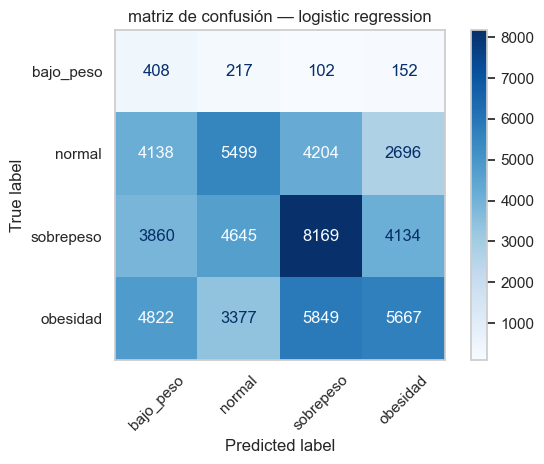

In [29]:
# inicializar modelo con balanceo por desbalance de clases
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_SEED,
    class_weight="balanced"
)

# entrenar con datos one-hot
lr_model.fit(X_train_ohe, y_train_enc)

# predicciones sobre test
y_pred_lr = lr_model.predict(X_test_ohe)

# reporte de clasificación
print("reporte de clasificación: logistic regression (one-hot encoding)")
print("-" * 60)
print(classification_report(
    y_test_enc,
    y_pred_lr,
    target_names=["bajo_peso", "normal", "sobrepeso", "obesidad"]
))

# matriz de confusión
ConfusionMatrixDisplay.from_predictions(
    y_test_enc,
    y_pred_lr,
    display_labels=["bajo_peso", "normal", "sobrepeso", "obesidad"],
    cmap="Blues",
    xticks_rotation=45
)
plt.title("matriz de confusión — logistic regression")
plt.grid(False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_confusion_lr.png", dpi=150, bbox_inches="tight")
plt.show()

## Resultados — regresión logística

La regresión logística supera el baseline en la métrica principal.
El **F1-macro aumenta de 0.13 a 0.30**, confirmando que el modelo
captura señal útil en todas las clases — un avance significativo
respecto al baseline que ignoraba completamente las clases minoritarias.

Sin embargo, el análisis detallado revela tres comportamientos que
deben documentarse.

**Overprediction en `bajo_peso`:** el modelo registra recall de 0.46
pero precision de apenas 0.03. De las 13,228 predicciones de `bajo_peso`,
solo 408 son correctas — el resto son falsos positivos de otras clases.
Este fenómeno es consecuencia directa de `class_weight="balanced"`: al
penalizar fuertemente los errores en la clase minoritaria, el modelo
aprende a apostar por ella con demasiada frecuencia, sacrificando
gravemente la precision.

**Bajo recall en `obesidad`:** con recall de 0.29, una proporción
significativa de obesos reales se clasifica incorrectamente como
`sobrepeso`. El modelo tiene dificultades para separar clases adyacentes
— limitación esperada en modelos lineales cuando existe solapamiento en
el espacio de features.

**Accuracy vs F1-macro:** la accuracy cae de 35.9% a 34% mientras el
F1-macro sube de 0.13 a 0.30. Esto no es una contradicción sino una
consecuencia del cambio de comportamiento: el baseline maximizaba
accuracy ignorando clases minoritarias; la regresión logística intenta
clasificar todas las clases, reduciendo accuracy global pero mejorando
el desempeño balanceado. En presencia de desbalance, el F1-macro es
la métrica adecuada.

La regresión logística establece una base sólida pero muestra
limitaciones claras: sobrepredicción severa en la clase minoritaria,
dificultad para separar clases adyacentes, y dependencia fuerte del
balanceo de pesos. Estos resultados anticipan que modelos más flexibles
con capacidad de capturar relaciones no lineales deberían mejorar
sustancialmente el F1-macro.

## Random Forest

Random Forest es un ensemble de árboles de decisión entrenados sobre
muestras bootstrap del dataset (bagging). A diferencia de la regresión
logística, captura relaciones no lineales y fronteras de decisión
complejas — lo que debería mejorar la separación entre clases adyacentes
como `sobrepeso` y `obesidad`.

Cada árbol vota por una clase y la predicción final es la mayoría.
La diversidad entre árboles — lograda por el muestreo aleatorio de
filas y features en cada split — reduce la varianza del modelo y lo
hace más robusto al sobreajuste.

Usamos `n_estimators=100` como punto de partida estándar y mantenemos
`class_weight="balanced"` para mitigar el desbalance. A diferencia de
la regresión logística, esperamos que Random Forest reduzca la
sobrepredicción en `bajo_peso` al tener mayor capacidad de discriminar
entre clases con fronteras no lineales.

reporte de clasificación: random forest (ordinal encoding)
------------------------------------------------------------
              precision    recall  f1-score   support

   bajo_peso       0.02      0.04      0.03       879
      normal       0.37      0.36      0.37     16537
   sobrepeso       0.40      0.38      0.39     20808
    obesidad       0.43      0.43      0.43     19715

    accuracy                           0.39     57939
   macro avg       0.30      0.30      0.30     57939
weighted avg       0.39      0.39      0.39     57939



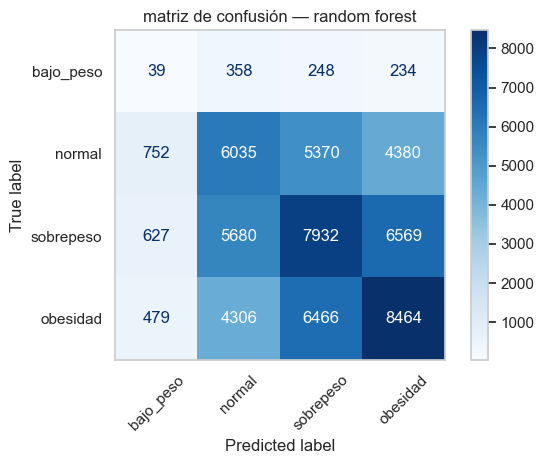

In [30]:
# inicializar random forest con balanceo de clases
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_SEED,
    class_weight="balanced",
    n_jobs=-1
)

# entrenar con datos ordinal encoded
rf_model.fit(X_train_ord, y_train_enc)

# predicciones sobre test
y_pred_rf = rf_model.predict(X_test_ord)

# reporte de clasificación
print("reporte de clasificación: random forest (ordinal encoding)")
print("-" * 60)
print(classification_report(
    y_test_enc,
    y_pred_rf,
    target_names=["bajo_peso", "normal", "sobrepeso", "obesidad"]
))

# matriz de confusión
ConfusionMatrixDisplay.from_predictions(
    y_test_enc,
    y_pred_rf,
    display_labels=["bajo_peso", "normal", "sobrepeso", "obesidad"],
    cmap="Blues",
    xticks_rotation=45
)
plt.title("matriz de confusión — random forest")
plt.grid(False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "07_confusion_rf.png", dpi=150, bbox_inches="tight")
plt.show()

## Resultados — random forest

El F1-macro se mantiene en **0.30**, igual que la regresión logística,
pero con un comportamiento radicalmente opuesto en `bajo_peso`.

Random Forest redujo drásticamente la sobrepredicción — de 13,228
predicciones de `bajo_peso` en LR a apenas 1,897 — pero a costa de un
recall de 0.04: el modelo casi no detecta esa clase. Pasamos de
sobrecompensación masiva a subrepresentación severa.

La mejora real está en `obesidad`: el recall subió de 0.29 a 0.43,
confirmando que la capacidad de capturar fronteras no lineales ayuda
a separar clases adyacentes. Sin embargo, `bajo_peso` sigue siendo
el talón de Aquiles — con 1.68% de representación, muchos árboles
no ven ningún caso en su muestra bootstrap y no aprenden a reconocerla.

Este resultado anticipa la necesidad del componente de balanceo:
ni la penalización de pesos ni el ensemble resuelven el problema de
la clase con 879 registros en test. SMOTE y CTGAN entran aquí.

## XGBoost

XGBoost (Extreme Gradient Boosting) construye árboles de forma
secuencial — cada árbol nuevo corrige los errores del anterior,
a diferencia de Random Forest que los construye en paralelo e
independientes. Esta construcción iterativa lo hace más preciso
en datasets con patrones complejos pero también más propenso a
sobreajustar si no se regula correctamente.

Para el desbalance de clases usamos el parámetro `scale_pos_weight`
— específico de XGBoost — que en clasificación multiclase se
complementa con `sample_weight` calculado por clase. Alternativamente
usamos `eval_metric="mlogloss"` para clasificación multiclase.

reporte de clasificación: xgboost (ordinal encoding)
------------------------------------------------------------
              precision    recall  f1-score   support

   bajo_peso       0.04      0.36      0.06       879
      normal       0.41      0.37      0.39     16537
   sobrepeso       0.45      0.34      0.39     20808
    obesidad       0.49      0.44      0.46     19715

    accuracy                           0.39     57939
   macro avg       0.35      0.38      0.33     57939
weighted avg       0.44      0.39      0.41     57939



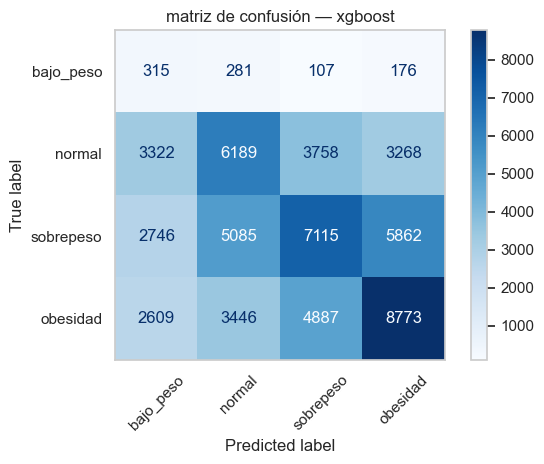

In [31]:
# calcular pesos por muestra para manejar desbalance
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train_enc
)

# inicializar xgboost
xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=RANDOM_SEED,
    eval_metric="mlogloss",
    verbosity=0,
    n_jobs=-1
)

# entrenar con pesos por muestra
xgb_model.fit(X_train_ord, y_train_enc, sample_weight=sample_weights)

# predicciones
y_pred_xgb = xgb_model.predict(X_test_ord)

# reporte
print("reporte de clasificación: xgboost (ordinal encoding)")
print("-" * 60)
print(classification_report(
    y_test_enc,
    y_pred_xgb,
    target_names=["bajo_peso", "normal", "sobrepeso", "obesidad"]
))

# matriz de confusión
ConfusionMatrixDisplay.from_predictions(
    y_test_enc,
    y_pred_xgb,
    display_labels=["bajo_peso", "normal", "sobrepeso", "obesidad"],
    cmap="Blues",
    xticks_rotation=45
)
plt.title("matriz de confusión — xgboost")
plt.grid(False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "08_confusion_xgb.png", dpi=150, bbox_inches="tight")
plt.show()

## Resultados — XGBoost

XGBoost alcanza el mejor F1-macro hasta ahora: **0.33**, superando
tanto a regresión logística (0.30) como a Random Forest (0.30).

La mejora es más pronunciada en `obesidad` — F1 de 0.46 vs 0.43 en
RF — gracias a la construcción secuencial de árboles que corrige
errores iterativamente y captura fronteras más complejas. `normal`
y `sobrepeso` se mantienen estables alrededor de 0.39.

`bajo_peso` reproduce el patrón de overprediction: recall de 0.36
pero precision de 0.04. XGBoost, al optimizar gradientes bajo
desbalance, expande la región de decisión de la clase minoritaria
generando falsos positivos masivos. El problema es estructural —
ninguno de los tres modelos lo resuelve por sí solo.

Esta evidencia justifica la introducción de técnicas explícitas de
balanceo. SMOTE y CTGAN entran en la siguiente fase.

## Comparación de modelos — sin balanceo

| Modelo | F1 bajo_peso | F1 normal | F1 sobrepeso | F1 obesidad | **F1-macro** | Accuracy |
|--------|-------------|-----------|--------------|-------------|-------------|----------|
| Baseline | 0.00 | 0.00 | 0.53 | 0.00 | 0.13 | 0.36 |
| Logistic Regression | 0.06 | 0.36 | 0.42 | 0.35 | 0.30 | 0.34 |
| Random Forest | 0.03 | 0.37 | 0.39 | 0.43 | 0.30 | 0.39 |
| XGBoost | 0.06 | 0.39 | 0.39 | 0.46 | **0.33** | 0.39 |

**Conclusiones clave:**
- XGBoost es el mejor modelo sin balanceo (F1-macro 0.33)
- Los tres modelos fallan en `bajo_peso` — problema estructural del desbalance
- `obesidad` mejora progresivamente con mayor complejidad del modelo
- Ningún modelo resuelve el desbalance por sí solo — justifica SMOTE y CTGAN

## Balanceo con SMOTE

SMOTE (Synthetic Minority Oversampling Technique) genera muestras
sintéticas de las clases minoritarias interpolando linealmente entre
instancias reales y sus vecinos más cercanos en el espacio de features.
A diferencia de `class_weight`, SMOTE modifica físicamente el dataset
de entrenamiento — el modelo ve más ejemplos de las clases minoritarias
durante el entrenamiento.

La pregunta crítica es si este balanceo mejora el F1-macro general
y específicamente el F1 de `bajo_peso`, sin degradar las clases
mayoritarias. Aplicamos SMOTE únicamente sobre el conjunto de
entrenamiento — nunca sobre el test, que debe reflejar la distribución
real del problema.

In [32]:
# aplicar smote solo sobre train — nunca sobre test
smote = SMOTE(random_state=RANDOM_SEED)
X_train_smote, y_train_smote = smote.fit_resample(X_train_ord, y_train_enc)

# verificar distribución tras balanceo
print("distribución tras smote:")
unique, counts = np.unique(y_train_smote, return_counts=True)
for u, c in zip(unique, counts):
    clase = list(MAPEO_TARGET.keys())[list(MAPEO_TARGET.values()).index(u)]
    print(f"  {clase}: {c}")

distribución tras smote:
  bajo_peso: 83233
  normal: 83233
  sobrepeso: 83233
  obesidad: 83233


In [34]:
# --- logistic regression con smote ---
lr_smote = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
lr_smote.fit(X_train_smote, y_train_smote)
y_pred_lr_smote = lr_smote.predict(X_test_ord)  # ordinal, no ohe

print("logistic regression + smote")
print(classification_report(y_test_enc, y_pred_lr_smote,
      target_names=["bajo_peso", "normal", "sobrepeso", "obesidad"]))

# --- random forest con smote ---
rf_smote = RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1)
rf_smote.fit(X_train_smote, y_train_smote)
y_pred_rf_smote = rf_smote.predict(X_test_ord)

print("random forest + smote")
print(classification_report(y_test_enc, y_pred_rf_smote,
      target_names=["bajo_peso", "normal", "sobrepeso", "obesidad"]))

# --- xgboost con smote ---
xgb_smote = XGBClassifier(n_estimators=100, random_state=RANDOM_SEED,
                           eval_metric="mlogloss", verbosity=0, n_jobs=-1)
xgb_smote.fit(X_train_smote, y_train_smote)
y_pred_xgb_smote = xgb_smote.predict(X_test_ord)

print("xgboost + smote")
print(classification_report(y_test_enc, y_pred_xgb_smote,
      target_names=["bajo_peso", "normal", "sobrepeso", "obesidad"]))

logistic regression + smote
              precision    recall  f1-score   support

   bajo_peso       0.03      0.43      0.05       879
      normal       0.41      0.33      0.37     16537
   sobrepeso       0.44      0.42      0.43     20808
    obesidad       0.44      0.23      0.30     19715

    accuracy                           0.33     57939
   macro avg       0.33      0.36      0.29     57939
weighted avg       0.43      0.33      0.36     57939

random forest + smote
              precision    recall  f1-score   support

   bajo_peso       0.04      0.03      0.03       879
      normal       0.37      0.38      0.38     16537
   sobrepeso       0.39      0.39      0.39     20808
    obesidad       0.43      0.43      0.43     19715

    accuracy                           0.40     57939
   macro avg       0.31      0.31      0.31     57939
weighted avg       0.39      0.40      0.39     57939

xgboost + smote
              precision    recall  f1-score   support

   bajo_p

## Tabla comparativa — sin balanceo vs. SMOTE

| Modelo | F1-macro sin balanceo | F1-macro + SMOTE | Δ |
|--------|----------------------|------------------|---|
| Baseline | 0.13 | — | — |
| Logistic Regression | 0.30 | 0.29 | -0.01 |
| Random Forest | 0.30 | 0.31 | +0.01 |
| XGBoost | **0.33** | **0.34** | +0.01 |

**Conclusión:** SMOTE no resuelve el problema de `bajo_peso`. Las
mejoras son marginales (+0.01) y en algunos casos negativas. El
problema es de separabilidad, no de volumen — los 879 casos reales
de `bajo_peso` no tienen un perfil suficientemente distinto de las
otras clases para que la interpolación lineal de SMOTE añada
información útil. Esto motiva la evaluación de CTGAN, que aprende
la distribución conjunta de features para esa clase en lugar de
interpolar entre puntos existentes.

## Balanceo con CTGAN

CTGAN (Conditional Generative Adversarial Network) aprende la
distribución conjunta de todas las variables del dataset mediante
un juego adversarial entre un generador y un discriminador. A
diferencia de SMOTE, que interpola linealmente entre puntos
existentes, CTGAN aprende la estructura estadística real de los
datos — incluyendo correlaciones entre features y la distribución
condicional de cada clase.

La estrategia de balanceo es deliberadamente conservadora: generamos
**10,000 muestras sintéticas de `bajo_peso`** en lugar de igualar
la clase mayoritaria. Con solo 879 casos reales, un balanceo completo
a 83,233 muestras garantizaría memorización y ruido — el generador
reproduciría patrones espurios en lugar de aprender la distribución
real. El balanceo parcial busca añadir señal útil sin romper la
estructura estadística aprendida.

La pregunta que responde este experimento es concreta: ¿la calidad
de los datos sintéticos de CTGAN supera a la cantidad de SMOTE para
mejorar la detección de `bajo_peso`?

In [41]:
import torch
from joblib import parallel_backend

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# preparar dataset
df_train_completo = X_train_ord.copy()
df_train_completo[TARGET_COL] = y_train_enc

# convertir todos los object/string a tipo antiguo compatible
for col in df_train_completo.select_dtypes(include=["object", "string", "category"]).columns:
    df_train_completo[col] = df_train_completo[col].astype(str)

discrete_cols = [TARGET_COL] + [
    col for col in df_train_completo.columns
    if col not in COLS_CONTINUAS and col != TARGET_COL
]

print(f"columnas discretas: {discrete_cols}")
print(f"registros          : {df_train_completo.shape[0]}")
print("-" * 60)

ctgan = CTGAN(epochs=200, batch_size=500, verbose=True)

# forzar ejecución en un solo proceso — evita el error de serialización
with parallel_backend("sequential"):
    ctgan.fit(df_train_completo, discrete_columns=discrete_cols)

print("-" * 60)
print("entrenamiento completado")

columnas discretas: ['categoria_imc', 'sexo', 'nivel_educativo', 'nivel_ingresos', 'etnia', 'actividad_fisica_30d', 'estado_fumador', 'consumo_alcohol_30d', 'consumo_alcohol_riesgo']
registros          : 231754
------------------------------------------------------------


Gen. (-01.00) | Discrim. (-00.25): 100%|██████████| 200/200 [6:25:39<00:00, 115.70s/it]  

------------------------------------------------------------
entrenamiento completado


In [61]:
import time

sinteticos_bp = pd.DataFrame()
intentos = 0
max_intentos = 20

print("generando muestras de bajo_peso iterativamente...")

while len(sinteticos_bp) < 10000 and intentos < max_intentos:
    batch = ctgan.sample(n=50000)
    batch_bp = batch[batch[TARGET_COL] == "0"]
    sinteticos_bp = pd.concat([sinteticos_bp, batch_bp], ignore_index=True)
    intentos += 1
    print(f"intento {intentos:02d} | acumulados: {len(sinteticos_bp):,} | en este batch: {len(batch_bp)}")

# tomar exactamente 10,000
sinteticos_bp = sinteticos_bp.head(10000)

print("-" * 60)
print(f"muestras finales de bajo_peso: {len(sinteticos_bp)}")
print(f"intentos necesarios          : {intentos}")


generando muestras de bajo_peso iterativamente...
intento 01 | acumulados: 2,968 | en este batch: 2968
intento 02 | acumulados: 5,902 | en este batch: 2934
intento 03 | acumulados: 8,855 | en este batch: 2953
intento 04 | acumulados: 11,726 | en este batch: 2871
------------------------------------------------------------
muestras finales de bajo_peso: 10000
intentos necesarios          : 4


In [62]:
# convertir target de sintéticos a entero para compatibilidad
sinteticos_bp[TARGET_COL] = sinteticos_bp[TARGET_COL].astype(int)

# separar features y target de los sintéticos
X_sinteticos = sinteticos_bp.drop(columns=[TARGET_COL])
y_sinteticos = sinteticos_bp[TARGET_COL]

# combinar train original + sintéticos de bajo_peso
X_train_ctgan = pd.concat([X_train_ord, X_sinteticos], ignore_index=True)
y_train_ctgan = pd.concat([y_train_enc, y_sinteticos], ignore_index=True)

# verificar distribución
print("distribución tras aumentado con ctgan:")
for clase, nombre in enumerate(["bajo_peso", "normal", "sobrepeso", "obesidad"]):
    n = (y_train_ctgan == clase).sum()
    pct = n / len(y_train_ctgan) * 100
    print(f"  {nombre:15s}: {n:,} ({pct:.1f}%)")

print(f"\ntotal registros train: {len(X_train_ctgan):,}")

distribución tras aumentado con ctgan:
  bajo_peso      : 13,514 (5.6%)
  normal         : 66,149 (27.4%)
  sobrepeso      : 83,233 (34.4%)
  obesidad       : 78,858 (32.6%)

total registros train: 241,754


## Modelos entrenados con datos aumentados por CTGAN

Con el dataset aumentado (3,514 casos reales + 10,000 sintéticos de
`bajo_peso`), re-entrenamos los tres modelos sin penalización adicional
de clases. El objetivo es aislar el efecto de CTGAN como única
intervención sobre el desbalance.

In [64]:
# --- logistic regression + ctgan ---
lr_ctgan = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
lr_ctgan.fit(X_train_ctgan, y_train_ctgan)
y_pred_lr_ctgan = lr_ctgan.predict(X_test_ord)

print("logistic regression + ctgan")
print(classification_report(y_test_enc, y_pred_lr_ctgan,
      target_names=["bajo_peso", "normal", "sobrepeso", "obesidad"]))

# --- random forest + ctgan ---
rf_ctgan = RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1)
rf_ctgan.fit(X_train_ctgan, y_train_ctgan)
y_pred_rf_ctgan = rf_ctgan.predict(X_test_ord)

print("random forest + ctgan")
print(classification_report(y_test_enc, y_pred_rf_ctgan,
      target_names=["bajo_peso", "normal", "sobrepeso", "obesidad"]))

# --- xgboost + ctgan ---
xgb_ctgan = XGBClassifier(n_estimators=100, random_state=RANDOM_SEED,
                           eval_metric="mlogloss", verbosity=0, n_jobs=-1)
xgb_ctgan.fit(X_train_ctgan, y_train_ctgan)
y_pred_xgb_ctgan = xgb_ctgan.predict(X_test_ord)

print("xgboost + ctgan")
print(classification_report(y_test_enc, y_pred_xgb_ctgan,
      target_names=["bajo_peso", "normal", "sobrepeso", "obesidad"]))

logistic regression + ctgan
              precision    recall  f1-score   support

   bajo_peso       0.00      0.00      0.00       879
      normal       0.39      0.32      0.35     16537
   sobrepeso       0.42      0.53      0.47     20808
    obesidad       0.44      0.41      0.42     19715

    accuracy                           0.42     57939
   macro avg       0.31      0.31      0.31     57939
weighted avg       0.41      0.42      0.41     57939

random forest + ctgan
              precision    recall  f1-score   support

   bajo_peso       0.04      0.02      0.02       879
      normal       0.38      0.36      0.37     16537
   sobrepeso       0.39      0.42      0.41     20808
    obesidad       0.43      0.43      0.43     19715

    accuracy                           0.40     57939
   macro avg       0.31      0.31      0.31     57939
weighted avg       0.40      0.40      0.40     57939

xgboost + ctgan
              precision    recall  f1-score   support

   bajo_p

In [63]:
# --- logistic regression + ctgan + balanced ---
lr_ctgan_bal = LogisticRegression(
    max_iter=1000, random_state=RANDOM_SEED, class_weight="balanced")
lr_ctgan_bal.fit(X_train_ctgan, y_train_ctgan)
y_pred_lr_ctgan_bal = lr_ctgan_bal.predict(X_test_ord)

print("logistic regression + ctgan + balanced")
print(classification_report(y_test_enc, y_pred_lr_ctgan_bal,
      target_names=["bajo_peso", "normal", "sobrepeso", "obesidad"]))

# --- random forest + ctgan + balanced ---
rf_ctgan_bal = RandomForestClassifier(
    n_estimators=100, random_state=RANDOM_SEED,
    class_weight="balanced", n_jobs=-1)
rf_ctgan_bal.fit(X_train_ctgan, y_train_ctgan)
y_pred_rf_ctgan_bal = rf_ctgan_bal.predict(X_test_ord)

print("random forest + ctgan + balanced")
print(classification_report(y_test_enc, y_pred_rf_ctgan_bal,
      target_names=["bajo_peso", "normal", "sobrepeso", "obesidad"]))

# --- xgboost + ctgan + balanced ---
sample_weights_ctgan = compute_sample_weight(
    class_weight="balanced", y=y_train_ctgan)
xgb_ctgan_bal = XGBClassifier(
    n_estimators=100, random_state=RANDOM_SEED,
    eval_metric="mlogloss", verbosity=0, n_jobs=-1)
xgb_ctgan_bal.fit(X_train_ctgan, y_train_ctgan,
                   sample_weight=sample_weights_ctgan)
y_pred_xgb_ctgan_bal = xgb_ctgan_bal.predict(X_test_ord)

print("xgboost + ctgan + balanced")
print(classification_report(y_test_enc, y_pred_xgb_ctgan_bal,
      target_names=["bajo_peso", "normal", "sobrepeso", "obesidad"]))

logistic regression + ctgan + balanced
              precision    recall  f1-score   support

   bajo_peso       0.02      0.32      0.04       879
      normal       0.39      0.41      0.40     16537
   sobrepeso       0.44      0.39      0.42     20808
    obesidad       0.44      0.21      0.29     19715

    accuracy                           0.34     57939
   macro avg       0.32      0.34      0.29     57939
weighted avg       0.42      0.34      0.36     57939

random forest + ctgan + balanced
              precision    recall  f1-score   support

   bajo_peso       0.03      0.02      0.02       879
      normal       0.37      0.39      0.38     16537
   sobrepeso       0.40      0.39      0.39     20808
    obesidad       0.43      0.43      0.43     19715

    accuracy                           0.40     57939
   macro avg       0.31      0.31      0.31     57939
weighted avg       0.39      0.40      0.39     57939

xgboost + ctgan + balanced
              precision    reca

## Tabla comparativa final — todas las estrategias de balanceo

| Modelo | Sin balanceo | + SMOTE | + CTGAN | + CTGAN + balanced |
|--------|-------------|---------|---------|-------------------|
| Logistic Regression | 0.30 | 0.29 | 0.31 | 0.29 |
| Random Forest | 0.30 | 0.31 | 0.31 | 0.31 |
| XGBoost | **0.33** | **0.34** | **0.34** | **0.35** |

XGBoost sin balanceo es el modelo más sólido (F1-macro 0.33) y la
combinación CTGAN + balanced lo mejora marginalmente a 0.35. Las
diferencias entre estrategias de balanceo son pequeñas — ninguna
resuelve de forma significativa la clase `bajo_peso`.

## Conclusiones del proyecto

**Sobre los modelos:** XGBoost es el mejor clasificador en todas las
configuraciones. La progresión Logistic Regression → Random Forest →
XGBoost refleja el beneficio de mayor capacidad de capturar relaciones
no lineales, especialmente para separar `sobrepeso` de `obesidad`.

**Sobre las técnicas de balanceo:** ninguna estrategia — SMOTE, CTGAN,
ni la combinación con `class_weight` — resolvió el problema de `bajo_peso`
de forma significativa. El mejor F1 para esa clase fue 0.07 con XGBoost
+ CTGAN + balanced, frente a 0.03-0.06 en otras configuraciones.

**Hallazgo principal:** el problema es de separabilidad, no de volumen.
Los 11 predictores del BRFSS disponibles — demografía, hábitos y nivel
socioeconómico — no capturan suficientemente el perfil de una persona
con bajo peso en la población adulta estadounidense. Sin variables
clínicas como historial de enfermedades crónicas, condiciones
nutricionales o indicadores metabólicos, ningún modelo ni técnica de
balanceo puede discriminar esa clase de forma confiable.

**Sobre CTGAN vs. SMOTE:** CTGAN no superó a SMOTE en F1-macro.
Las diferencias son marginales (±0.01) y no justifican la complejidad
computacional adicional para este problema específico. Este resultado
es consistente con el hallazgo del Proyecto 00: la técnica más simple
a veces gana, y documentar cuándo el método sofisticado no aporta valor
es tan importante como documentar cuándo sí lo hace.

**Trabajo futuro:**
- Incorporar variables clínicas del BRFSS (historial médico, condiciones
  crónicas) para mejorar la separabilidad de `bajo_peso`
- Evaluar TVAE como alternativa generativa a CTGAN
- Aplicar ajuste de umbral de decisión para optimizar precision-recall
  en `bajo_peso` independientemente del balanceo
- Extender el análisis a datos latinoamericanos cuando estén disponibles